In [5]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from astropy.io import fits

%matplotlib inline

Getting the preprocessed CFLIB data :

In [6]:
cflib_path = "../preprocessing/preprocess_cflib_vyom.npy"

cflib_flux = np.load(cflib_path)

Getting the names of the stars: 

In [7]:
cflib_preprocessed_stars = np.load("../preprocessing/cflib_data.npz")["fname"]

Creating dataframe for the MILES stars with their atmospheric parameters : 

In [8]:
df = pd.read_csv("miles_selected.dat")

In [9]:
df.head()

,Miles,Name,Teff,[Fe/H],logg
0,1,HD 224930,5411,-0.78,4.19
1,2,HD 225212,4179,0.18,0.85
2,3,HD 225239,5559,-0.51,3.72
3,4,HD 00004,6779,0.21,3.87
4,5,HD 00249,4766,-0.27,2.91


#### Stars of interest : 
* HD 10307 -- 0066
* HD 10700 -- 0067
* HD 10975 -- 0070
* HD 13555 -- 0079


Initializing the interpolator: 

In [10]:
INTERPOLATOR_MODEL = '../../models/RF_base_model_pvk.sav'
STANDARD_SCALER = '../../models/rf_standard_scale_pvk.sav'

In [11]:
from sklearn.externals import joblib

sc = joblib.load(STANDARD_SCALER)
ip = joblib.load(INTERPOLATOR_MODEL)

In [12]:
ip.n_jobs = 1 

def InterpolateSpectrum(temperature, gravity, metallicity):
    X = np.array([temperature, gravity, metallicity]).reshape(1, -1)
    X_std = sc.transform(X)
    y = ip.predict(X_std)
    return y

### HD 10307 (s0066)

In [ ]:
path_10307 = "../../FITS_data/s0066.fits"       # defining the path of the fits file

Checking the structure of the fits file

In [ ]:
with fits.open(path_10307) as data_10307:           

    data_10307.info()

    hdr = data_10307[0].header          # header of primary HDU 
    flux = data_10307[0].data[0]        # flux data from the primary HDU 

hdr

Filename: ../../FITS_data/s0066.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      18   (4367, 1)   float32   


SIMPLE  =                    T / file does conform to FITS standard             
BITPIX  =                  -32 / number of bits per data pixel                  
NAXIS   =                    2 / number of data axes                            
NAXIS1  =                 4367 / length of data axis 1                          
NAXIS2  =                    1 / length of data axis 2                          
COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H 
COMMENT ----------------------------------------------------------------------  
COMMENT ************************** REDUCEME HEADER ***************************  
COMMENT ----------------------------------------------------------------------  
HISTORY Date: 06/10/**                                                          
CRPIX1  =                 1.00                                                  
CRVAL1  =            3500.00

Masking the wavelength grid from 4367 to 4306 points

In [15]:
final_wave = 3536. + np.arange(4306) * 0.9
original_wave = 3500. + np.arange(4367) * 0.9

# trimming the indexes to make the 4367 points to 4306 wavelength points

low_idx = np.argmin(abs(original_wave - final_wave[0]))
high_idx = np.argmin(abs(original_wave - final_wave[-1]))


In [ ]:
with fits.open(path_10307) as data_10307:

    hdr = data_10307[0].header

    flux_10307 = data_10307[0].data[0]

    flux_10307 = flux_10307[low_idx : high_idx + 1]     # masking the flux array

In [ ]:
df[df["Name"] == "HD 10307"]        # getting the atmospheric parameters for the star


,Miles,Name,Teff,[Fe/H],logg
65,66,HD 10307,5875,0.06,4.28


In [ ]:
pred = InterpolateSpectrum(temperature= 5875, gravity= 4.28, metallicity= 0.06)         # predicting flux using the random forest interpolator

Finding the index for the star in the cflib preprocessed (sharma et al):

In [ ]:
for i in range(len(cflib_preprocessed_stars)):              
    if cflib_preprocessed_stars[i] == "10307.fits":
        print(i)

6


In [21]:
flux_10307_vyom = cflib_flux[6]

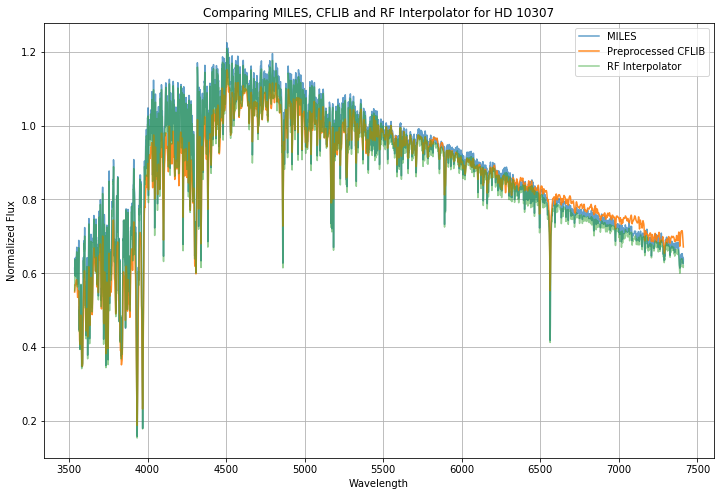

In [29]:
plt.figure(figsize= (12,8))
plt.title("Comparing MILES, CFLIB and RF Interpolator for HD 10307")
plt.plot(final_wave, flux_10307, label = "MILES", alpha = 0.7)
plt.plot(final_wave, flux_10307_vyom, label = "Preprocessed CFLIB", alpha = 0.9)
plt.plot(final_wave, pred[0,:], label = "RF Interpolator", alpha = 0.5)
plt.xlabel("Wavelength")
plt.ylabel("Normalized Flux")
plt.legend()
plt.grid()

### HD 10700 (s0067)

In [30]:
path_10700 = "../../FITS_data/s0067.fits"

In [35]:
with fits.open(path_10700) as data_10700:

    flux_10700 = data_10700[0].data[0]

    flux_10700 = flux_10700[low_idx : high_idx + 1]

flux_10700

array([0.4619998 , 0.44146457, 0.45398253, ..., 0.7051845 , 0.70380896,
       0.71534526], dtype=float32)

In [40]:
df[df["Name"] == "HD 10700"]

,Miles,Name,Teff,[Fe/H],logg
66,67,HD 10700,5348,-0.46,4.39


In [41]:
pred = InterpolateSpectrum(temperature= 5348, gravity= 4.39, metallicity= -0.46)

In [42]:
for i in range(len(cflib_preprocessed_stars)):
    if cflib_preprocessed_stars[i] == "10700.fits":
        print(i)

22


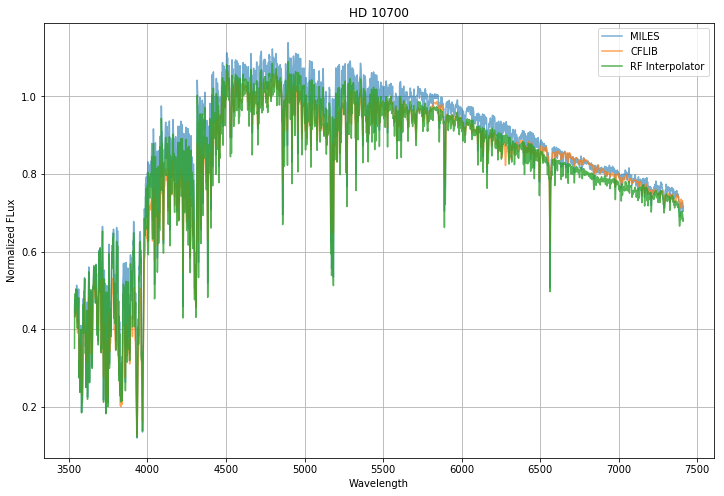

In [44]:
plt.figure(figsize= (12,8))
plt.title("HD 10700")
plt.plot(final_wave, flux_10700, label = "MILES", alpha = 0.6)
plt.plot(final_wave, cflib_flux[22], label = "CFLIB", alpha = 0.7)
plt.plot(final_wave, pred[0,:], label = "RF Interpolator", alpha = 0.8)
plt.grid()
plt.xlabel("Wavelength")
plt.ylabel("Normalized FLux")
plt.legend()

